# Laboratorio 5 – Naive Bayes  


**Objetivo de este notebook.**  
En este avance se construyen los modelos de **Naive Bayes** para:
1. **predicción del precio** de las viviendas, y  
2. **clasificación** de la categoría de precio (**Económica, Intermedia, Cara**),  

manteniendo exactamente la misma lógica de limpieza, la misma variable categórica y los mismos conjuntos de **entrenamiento/prueba** utilizados en el laboratorio anterior, para que las comparaciones sean válidas.

**Nota metodológica importante.**  
`GaussianNB` en `scikit-learn` es un clasificador. Para resolver el inciso de “regresión con Naive Bayes”, se implementa una estrategia reproducible y explícita: se discretiza el precio de entrenamiento en bandas, se entrena un clasificador Naive Bayes sobre esas bandas y luego la predicción de cada banda se traduce a un valor continuo usando la **mediana del precio** de la banda predicha. Esta decisión se documenta porque permite conservar el espíritu del método y usar métricas de regresión sobre una salida continua.


## 0. Librerías y utilidades

In [15]:

try:
    import pyreadr
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyreadr", "-q"])
    import pyreadr

import warnings
warnings.filterwarnings("ignore")

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace("$","").replace(",","")
    try:
        return float(s)
    except:
        return np.nan

def parse_pct(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace("%","")
    if s == "" or s.lower() == "nan":
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def parse_numeric(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",","")
    if s == "" or s.lower() == "nan":
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def count_list_like(series):
    s = series.fillna("").astype(str)
    quoted = s.str.count(r'"')
    counts = (quoted // 2).astype(float)
    fallback = s.str.count(",") + 1
    counts = counts.where(s.str.len() > 0, np.nan)
    counts = counts.where(counts > 0, fallback.astype(float))
    return counts

def make_pre(num, cat, dense=False, scale_num=False):
    num_steps = [("imp", SimpleImputer(strategy="median"))]
    if scale_num:
        num_steps.append(("scaler", StandardScaler()))
    cat_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=not dense)
    return ColumnTransformer([
        ("num", Pipeline(num_steps), num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", cat_ohe)
        ]), cat)
    ], sparse_threshold=0.0 if dense else 1.0)

def prepare_dense_nb(Xtrain, Xtest, num_cols, cat_cols, scale=True):
    imp_num = SimpleImputer(strategy="median")
    Xtr_num = pd.DataFrame(imp_num.fit_transform(Xtrain[num_cols]), columns=num_cols, index=Xtrain.index)
    Xte_num = pd.DataFrame(imp_num.transform(Xtest[num_cols]), columns=num_cols, index=Xtest.index)

    if scale:
        scaler = StandardScaler()
        Xtr_num = pd.DataFrame(scaler.fit_transform(Xtr_num), columns=num_cols, index=Xtrain.index)
        Xte_num = pd.DataFrame(scaler.transform(Xte_num), columns=num_cols, index=Xtest.index)

    imp_cat = SimpleImputer(strategy="most_frequent")
    Xtr_cat = pd.DataFrame(imp_cat.fit_transform(Xtrain[cat_cols]), columns=cat_cols, index=Xtrain.index)
    Xte_cat = pd.DataFrame(imp_cat.transform(Xtest[cat_cols]), columns=cat_cols, index=Xtest.index)

    Xtr_cat = pd.get_dummies(Xtr_cat.astype(str), drop_first=False)
    Xte_cat = pd.get_dummies(Xte_cat.astype(str), drop_first=False)
    Xte_cat = Xte_cat.reindex(columns=Xtr_cat.columns, fill_value=0)

    Xtr = pd.concat([Xtr_num, Xtr_cat], axis=1).astype(float).values
    Xte = pd.concat([Xte_num, Xte_cat], axis=1).astype(float).values
    return Xtr, Xte

def nb_regression_binned(Xtr, ytr, Xte, n_bins=6, var_smoothing=1e-3):
    ytr = pd.Series(ytr).reset_index(drop=True)
    codes, bins = pd.qcut(ytr, q=n_bins, labels=False, retbins=True, duplicates="drop")
    codes = pd.Series(codes).astype(int)

    model = GaussianNB(var_smoothing=var_smoothing)
    model.fit(Xtr, codes)

    band_summary = pd.DataFrame({
        "banda": sorted(codes.unique())
    })
    band_summary["mediana_precio"] = band_summary["banda"].map(ytr.groupby(codes).median())
    band_summary["media_precio"] = band_summary["banda"].map(ytr.groupby(codes).mean())
    band_summary["n"] = band_summary["banda"].map(codes.value_counts().sort_index())

    pred_codes = model.predict(Xte)
    pred = band_summary.set_index("banda").loc[pred_codes, "mediana_precio"].values
    return pred, pred_codes, model, band_summary, bins


## 1. Carga y preprocesamiento del conjunto de datos

En esta sección se **reconstruye exactamente** la limpieza usada en el laboratorio anterior para asegurar comparabilidad:
- se convierte el precio a formato numérico,
- se generan variables derivadas útiles,
- se eliminan filas sin precio,
- y se recorta el target a precios de hasta **USD 5,000 por noche**, tal como ya se justificó en el análisis exploratorio del laboratorio previo.


In [16]:

rdata_path = "listings.RData"
result = pyreadr.read_r(rdata_path)
df_raw = list(result.values())[0].copy()

print("Filas originales:", df_raw.shape[0])
print("Columnas originales:", df_raw.shape[1])

df = df_raw.copy()

for c in ["last_scraped","host_since","calendar_last_scraped","first_review","last_review"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

df["price_num"] = df["price"].map(parse_money)
df["host_response_rate_num"] = df["host_response_rate"].map(parse_pct)
df["host_acceptance_rate_num"] = df["host_acceptance_rate"].map(parse_pct)

for c in ["beds","bedrooms","host_listings_count","host_total_listings_count",
          "minimum_minimum_nights","maximum_minimum_nights","minimum_maximum_nights",
          "maximum_maximum_nights","estimated_revenue_l365d"]:
    if c in df.columns:
        df[c] = df[c].map(parse_numeric)

df["bathrooms_num"] = df["bathrooms"].where(
    df["bathrooms"].notna(),
    df["bathrooms_text"].fillna("").astype(str).str.extract(r"(\d+(\.\d+)?)")[0].astype(float)
)

df["amenities_count"] = count_list_like(df["amenities"])
df["host_verifications_count"] = count_list_like(df["host_verifications"])
df["description_length"] = df["description"].fillna("").astype(str).str.len()
df["host_about_length"] = df["host_about"].fillna("").astype(str).str.len()
df["neighborhood_overview_length"] = df["neighborhood_overview"].fillna("").astype(str).str.len()
df["name_length"] = df["name"].fillna("").astype(str).str.len()

ref_date = df["last_scraped"].max()
df["host_tenure_days"] = (ref_date - df["host_since"]).dt.days
df["days_since_first_review"] = (ref_date - df["first_review"]).dt.days
df["days_since_last_review"] = (ref_date - df["last_review"]).dt.days

for c in ["host_is_superhost","host_has_profile_pic","host_identity_verified","has_availability","instant_bookable"]:
    if c in df.columns:
        df[c] = df[c].replace({"t":"Sí","f":"No","":"Desconocido"}).fillna("Desconocido")

df_clean = df[df["price_num"].notna()].copy()
df_clean = df_clean[df_clean["price_num"] <= 5000].copy()

display(pd.DataFrame({
    "etapa": ["Datos originales", "Con precio no nulo", "Con precio <= 5000"],
    "filas": [len(df_raw), df["price_num"].notna().sum(), len(df_clean)]
}))


Filas originales: 171748
Columnas originales: 80


,etapa,filas
0,Datos originales,171748
1,Con precio no nulo,76246
2,Con precio <= 5000,75129


## 2. Reconstrucción de la variable categórica y de los mismos conjuntos train/test

La instrucción del laboratorio exige que las comparaciones se hagan **bajo las mismas condiciones**.  
Por eso se reutiliza la misma lógica del laboratorio anterior:

- **regresión:** partición estratificada usando quintiles del precio;
- **clasificación:** partición estratificada usando la variable categórica `price_category`;
- **categorías de precio:** se vuelven a crear con los mismos cortes basados en cuantiles:
  - Económica: hasta el percentil 33,
  - Intermedia: entre percentil 33 y 66,
  - Cara: por encima del percentil 66.


In [17]:

lean_num = [
    "latitude","longitude","accommodates","bathrooms_num","bedrooms","beds",
    "minimum_nights","availability_365","number_of_reviews","number_of_reviews_ltm",
    "review_scores_rating","review_scores_cleanliness","review_scores_location","reviews_per_month",
    "host_response_rate_num","host_acceptance_rate_num","calculated_host_listings_count",
    "amenities_count","host_verifications_count","description_length","host_about_length",
    "host_tenure_days","days_since_last_review","estimated_occupancy_l365d"
]
lean_cat = [
    "city","neighbourhood_cleansed","property_type","room_type","host_response_time",
    "host_is_superhost","host_identity_verified","instant_bookable"
]

lean_num = [c for c in lean_num if c in df_clean.columns]
lean_cat = [c for c in lean_cat if c in df_clean.columns]

# Variable categórica del Lab 4
q_33 = df_clean["price_num"].quantile(1/3)
q_66 = df_clean["price_num"].quantile(2/3)

def categorize_price(p):
    if p <= q_33:
        return "Económica"
    elif p <= q_66:
        return "Intermedia"
    else:
        return "Cara"

df_clean["price_category"] = df_clean["price_num"].apply(categorize_price)

# Conjuntos para regresión
X_reg = df_clean[lean_num + lean_cat].copy()
y_reg = df_clean["price_num"].copy()
price_bins = pd.qcut(y_reg, q=5, labels=False, duplicates="drop")

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42, stratify=price_bins
)

# Conjuntos para clasificación
X_clf = df_clean[lean_num + lean_cat].copy()
y_clf = df_clean["price_category"].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

display(pd.DataFrame({
    "Conjunto": ["Train regresión", "Test regresión", "Train clasificación", "Test clasificación"],
    "Filas": [len(X_train_reg), len(X_test_reg), len(X_train_clf), len(X_test_clf)]
}))

display(pd.DataFrame({
    "Corte": ["Percentil 33", "Percentil 66"],
    "Valor": [q_33, q_66]
}))

display(df_clean["price_category"].value_counts().rename_axis("categoría").to_frame("conteo"))


,Conjunto,Filas
0,Train regresión,60103
1,Test regresión,15026
2,Train clasificación,60103
3,Test clasificación,15026


,Corte,Valor
0,Percentil 33,141.0
1,Percentil 66,262.0


,conteo
categoría,
Económica,25185
Intermedia,24997
Cara,24947


## 3. Modelos de referencia del laboratorio anterior

Antes de entrenar Naive Bayes, se vuelven a ajustar los **mejores modelos previos** para que la comparación sea limpia y trazable:

- **Regresión lineal / Ridge**
- **Árbol de regresión**
- **Random Forest de regresión**
- **Árbol de clasificación** y **Random Forest de clasificación** como referencia adicional para la parte categórica

Esto no sustituye el trabajo anterior; solo reconstruye los resultados sobre la misma base para poder comparar directamente con Naive Bayes.


In [18]:

# Subconjuntos heredados del Lab 4
geo_num = [c for c in [
    "latitude","longitude","accommodates","bathrooms_num","bedrooms","beds",
    "minimum_nights","amenities_count"
] if c in lean_num]
geo_cat = [c for c in ["city","neighbourhood_cleansed","property_type","room_type"] if c in lean_cat]

demand_num = [c for c in [
    "availability_365","number_of_reviews","number_of_reviews_ltm","review_scores_rating",
    "review_scores_cleanliness","review_scores_location","reviews_per_month",
    "host_response_rate_num","host_acceptance_rate_num","host_tenure_days",
    "days_since_last_review","estimated_occupancy_l365d"
] if c in lean_num]
demand_cat = [c for c in ["host_response_time","host_is_superhost","host_identity_verified","instant_bookable"] if c in lean_cat]

curated_num = [c for c in [
    "latitude","longitude","accommodates","bathrooms_num","bedrooms","beds",
    "minimum_nights","availability_365","number_of_reviews","review_scores_rating",
    "review_scores_location","reviews_per_month","amenities_count","host_tenure_days",
    "estimated_occupancy_l365d"
] if c in lean_num]
curated_cat = [c for c in [
    "city","neighbourhood_cleansed","property_type","room_type","host_is_superhost","instant_bookable"
] if c in lean_cat]

lin_num = [
    "accommodates","bathrooms_num","bedrooms","beds","minimum_nights","availability_365",
    "number_of_reviews","number_of_reviews_ltm","review_scores_rating","review_scores_cleanliness",
    "review_scores_location","reviews_per_month","host_response_rate_num","host_acceptance_rate_num",
    "calculated_host_listings_count","amenities_count","host_tenure_days","estimated_occupancy_l365d"
]
lin_num = [c for c in lin_num if c in df_clean.columns]
lin_cat_basic = ["city","room_type","host_is_superhost","instant_bookable"]
lin_cat_property = ["city","room_type","property_type","host_is_superhost","instant_bookable"]

# Mejor árbol de regresión del Lab 4
tree_pre = make_pre(curated_num, curated_cat, dense=False, scale_num=False)
tree_reg = Pipeline([
    ("pre", tree_pre),
    ("model", DecisionTreeRegressor(max_depth=14, min_samples_leaf=10, random_state=42))
])
tree_reg.fit(X_train_reg[curated_num + curated_cat], y_train_reg)
pred_tree_reg = tree_reg.predict(X_test_reg[curated_num + curated_cat])

# Mejor lineal del Lab 4 en RMSE/R2
X_lin_property = df_clean[lin_num + lin_cat_property].copy()
y_lin = df_clean["price_num"].copy()
bins_lin = pd.qcut(y_lin, q=5, labels=False, duplicates="drop")
X_train_lin_p, X_test_lin_p, y_train_lin_p, y_test_lin_p = train_test_split(
    X_lin_property, y_lin, test_size=0.20, random_state=42, stratify=bins_lin
)

pre_lin_property = make_pre(lin_num, lin_cat_property, dense=False, scale_num=True)
ridge_reg = Pipeline([
    ("pre", pre_lin_property),
    ("model", Ridge(alpha=1.0))
])
ridge_reg.fit(X_train_lin_p, y_train_lin_p)
pred_ridge_reg = ridge_reg.predict(X_test_lin_p)

# Random Forest de regresión del Lab 4
rf_pre = make_pre(curated_num, curated_cat, dense=False, scale_num=False)
rf_reg = Pipeline([
    ("pre", rf_pre),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=18,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])
rf_reg.fit(X_train_reg[curated_num + curated_cat], y_train_reg)
pred_rf_reg = rf_reg.predict(X_test_reg[curated_num + curated_cat])

reg_reference = pd.DataFrame([
    {
        "Modelo": "Regresión lineal / Ridge",
        "MAE": mean_absolute_error(y_test_lin_p, pred_ridge_reg),
        "RMSE": rmse(y_test_lin_p, pred_ridge_reg),
        "R2": r2_score(y_test_lin_p, pred_ridge_reg)
    },
    {
        "Modelo": "Árbol de regresión",
        "MAE": mean_absolute_error(y_test_reg, pred_tree_reg),
        "RMSE": rmse(y_test_reg, pred_tree_reg),
        "R2": r2_score(y_test_reg, pred_tree_reg)
    },
    {
        "Modelo": "Random Forest regresión",
        "MAE": mean_absolute_error(y_test_reg, pred_rf_reg),
        "RMSE": rmse(y_test_reg, pred_rf_reg),
        "R2": r2_score(y_test_reg, pred_rf_reg)
    }
]).round(4)

display(reg_reference.sort_values("R2", ascending=False))

# Clasificación 
pre_clf = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), lean_num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]), lean_cat)
], sparse_threshold=1.0)

tree_clf = Pipeline([
    ("pre", pre_clf),
    ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42))
])
tree_clf.fit(X_train_clf, y_train_clf)
pred_tree_clf = tree_clf.predict(X_test_clf)

rf_clf_pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), curated_num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]), curated_cat)
], sparse_threshold=1.0)

rf_clf = Pipeline([
    ("pre", rf_clf_pre),
    ("model", RandomForestClassifier(
        n_estimators=120,
        max_depth=16,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])
rf_clf.fit(X_train_clf[curated_num + curated_cat], y_train_clf)
pred_rf_clf = rf_clf.predict(X_test_clf[curated_num + curated_cat])

clf_reference = pd.DataFrame([
    {
        "Modelo": "Árbol de clasificación (Lab 4)",
        "Accuracy": accuracy_score(y_test_clf, pred_tree_clf),
        "Precision_macro": precision_score(y_test_clf, pred_tree_clf, average="macro"),
        "Recall_macro": recall_score(y_test_clf, pred_tree_clf, average="macro"),
        "F1_macro": f1_score(y_test_clf, pred_tree_clf, average="macro")
    },
    {
        "Modelo": "Random Forest clasificación ",
        "Accuracy": accuracy_score(y_test_clf, pred_rf_clf),
        "Precision_macro": precision_score(y_test_clf, pred_rf_clf, average="macro"),
        "Recall_macro": recall_score(y_test_clf, pred_rf_clf, average="macro"),
        "F1_macro": f1_score(y_test_clf, pred_rf_clf, average="macro")
    }
]).round(4)

display(clf_reference.sort_values("F1_macro", ascending=False))


,Modelo,MAE,RMSE,R2
1,Árbol de regresión,111.5300,247.2076,0.5925
2,Random Forest regresión,117.3061,251.3245,0.5789
0,Regresión lineal / Ridge,156.5261,300.3593,0.3985


,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro
1,Random Forest clasificación,0.7138,0.7102,0.7137,0.7115
0,Árbol de clasificación (Lab 4),0.6336,0.6811,0.6335,0.6399


## 4. Incisos 1 y 2 – Naive Bayes para predicción del precio

### Decisión metodológica
Como `GaussianNB` es un clasificador, se implementa una versión operativa de regresión en tres pasos:

1. se toma el **precio de entrenamiento** y se divide en bandas por cuantiles;
2. se entrena Naive Bayes para predecir en qué banda cae una vivienda;
3. la banda predicha se traduce a un precio continuo usando la **mediana** de esa banda.

Se usa la **mediana** y no la media para devolver el precio porque la distribución es asimétrica a la derecha; por lo tanto, la mediana es más robusta a colas y valores altos.


In [28]:

# Candidatos para justificar la selección del modelo NB de regresión
nb_reg_candidate_rows = []

reg_feature_sets = {
    "compacto": (
        [c for c in ["accommodates","bathrooms_num","bedrooms","beds","minimum_nights",
                     "availability_365","number_of_reviews","review_scores_rating",
                     "review_scores_location","reviews_per_month","amenities_count",
                     "host_tenure_days","estimated_occupancy_l365d"] if c in X_train_reg.columns],
        [c for c in ["city","room_type","property_type","host_is_superhost","instant_bookable"] if c in X_train_reg.columns]
    ),
    "lineal_basico": (
        lin_num,
        lin_cat_basic
    ),
    "curado_EDA": (
        curated_num,
        curated_cat
    )
}

for subset_name, (num_cols, cat_cols) in reg_feature_sets.items():
    Xtr_nb, Xte_nb = prepare_dense_nb(
        X_train_reg[num_cols + cat_cols],
        X_test_reg[num_cols + cat_cols],
        num_cols,
        cat_cols,
        scale=True
    )
    for n_bins in [2, 3, 4, 5, 6, 8]:
        pred_tmp, _, _, _, _ = nb_regression_binned(
            Xtr_nb, y_train_reg.values, Xte_nb,
            n_bins=n_bins, var_smoothing=1e-3
        )
        nb_reg_candidate_rows.append({
            "subset": subset_name,
            "bandas_precio": n_bins,
            "MAE": mean_absolute_error(y_test_reg, pred_tmp),
            "RMSE": rmse(y_test_reg, pred_tmp),
            "R2": r2_score(y_test_reg, pred_tmp)
        })

nb_reg_candidates = pd.DataFrame(nb_reg_candidate_rows).sort_values(
    ["R2", "RMSE"], ascending=[False, True]
).round(4)

display(nb_reg_candidates)


,subset,bandas_precio,MAE,RMSE,R2
10,lineal_basico,6,160.9995,342.4972,0.2179
9,lineal_basico,5,156.8204,344.7206,0.2077
11,lineal_basico,8,176.2498,348.3791,0.1908
8,lineal_basico,4,155.8588,351.0827,0.1782
7,lineal_basico,3,155.1888,358.5699,0.1428
1,compacto,3,190.0417,367.5786,0.0992
2,compacto,4,205.1559,369.1399,0.0915
13,curado_EDA,3,190.7397,369.5484,0.0895
12,curado_EDA,2,173.3328,374.9068,0.0629
6,lineal_basico,2,167.6654,374.9965,0.0624


### Selección del mejor Naive Bayes de regresión

Se elige el modelo **NB con subconjunto lineal básico y 6 bandas de precio**, porque fue el que produjo el mejor equilibrio de **R²** y **RMSE** dentro de las configuraciones probadas.


In [20]:

# Mejor NB de regresión
best_nb_reg_num = reg_feature_sets["lineal_basico"][0]
best_nb_reg_cat = reg_feature_sets["lineal_basico"][1]

Xtr_nb_reg, Xte_nb_reg = prepare_dense_nb(
    X_train_reg[best_nb_reg_num + best_nb_reg_cat],
    X_test_reg[best_nb_reg_num + best_nb_reg_cat],
    best_nb_reg_num,
    best_nb_reg_cat,
    scale=True
)

pred_nb_reg, pred_nb_reg_codes, nb_reg_model, nb_reg_band_summary, nb_reg_bins = nb_regression_binned(
    Xtr_nb_reg, y_train_reg.values, Xte_nb_reg,
    n_bins=6, var_smoothing=1e-3
)

pred_nb_reg_train, _, _, _, _ = nb_regression_binned(
    Xtr_nb_reg, y_train_reg.values, Xtr_nb_reg,
    n_bins=6, var_smoothing=1e-3
)

nb_reg_metrics = pd.DataFrame({
    "Métrica": ["MAE entrenamiento", "RMSE entrenamiento", "R² entrenamiento",
                "MAE prueba", "RMSE prueba", "R² prueba"],
    "Valor": [
        mean_absolute_error(y_train_reg, pred_nb_reg_train),
        rmse(y_train_reg, pred_nb_reg_train),
        r2_score(y_train_reg, pred_nb_reg_train),
        mean_absolute_error(y_test_reg, pred_nb_reg),
        rmse(y_test_reg, pred_nb_reg),
        r2_score(y_test_reg, pred_nb_reg)
    ]
}).round(4)

display(nb_reg_band_summary.round(2))
display(nb_reg_metrics)


,banda,mediana_precio,media_precio,n
0,0,75.0,70.61,10303
1,1,120.0,120.14,9888
2,2,165.0,165.63,9933
3,3,222.0,223.52,10034
4,4,318.0,324.97,9931
5,5,643.0,878.43,10014


,Métrica,Valor
0,MAE entrenamiento,159.1653
1,RMSE entrenamiento,334.6701
2,R² entrenamiento,0.2198
3,MAE prueba,160.9995
4,RMSE prueba,342.4972
5,R² prueba,0.2179


,n,mae,mean_error,actual_median,pred_median
segmento,,,,,
Económica,4994,55.36,44.89,98.0,120.0
Intermedia,5030,110.68,45.03,190.0,165.0
Cara,5002,317.07,-180.21,414.0,318.0


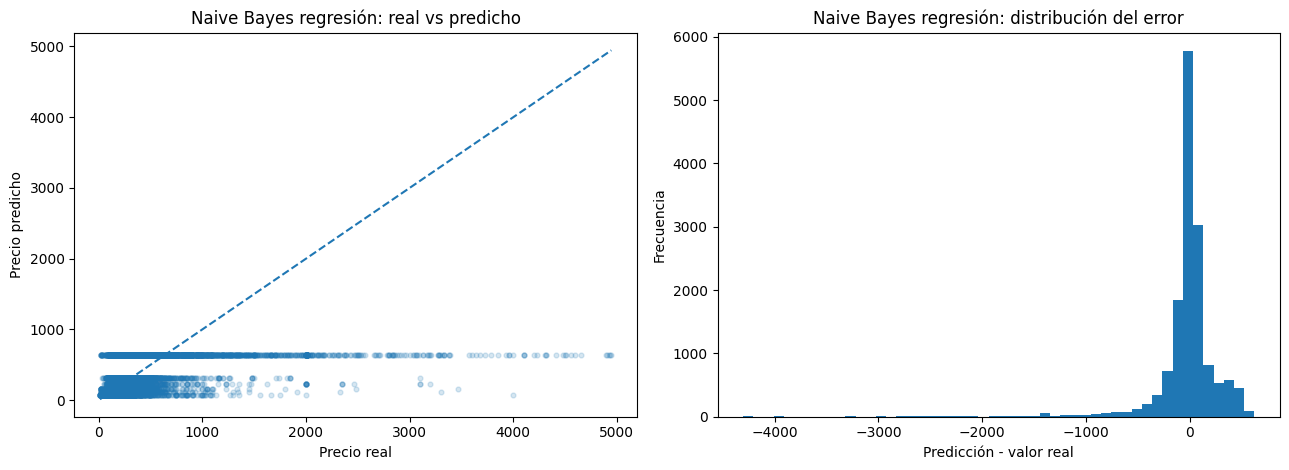

In [21]:

# Gráficas e interpretación del ajuste NB regresión
nb_reg_eval = pd.DataFrame({
    "actual": y_test_reg.values,
    "pred": pred_nb_reg
})
nb_reg_eval["error"] = nb_reg_eval["pred"] - nb_reg_eval["actual"]
nb_reg_eval["segmento"] = pd.cut(
    nb_reg_eval["actual"],
    bins=[-np.inf, q_33, q_66, np.inf],
    labels=["Económica","Intermedia","Cara"]
)

nb_reg_segment_analysis = nb_reg_eval.groupby("segmento").agg(
    n=("actual","size"),
    mae=("error", lambda s: np.mean(np.abs(s))),
    mean_error=("error","mean"),
    actual_median=("actual","median"),
    pred_median=("pred","median")
).round(2)

display(nb_reg_segment_analysis)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].scatter(y_test_reg, pred_nb_reg, alpha=0.18, s=12)
lims = [min(y_test_reg.min(), pred_nb_reg.min()), max(y_test_reg.max(), pred_nb_reg.max())]
ax[0].plot(lims, lims, linestyle="--")
ax[0].set_title("Naive Bayes regresión: real vs predicho")
ax[0].set_xlabel("Precio real")
ax[0].set_ylabel("Precio predicho")

ax[1].hist(nb_reg_eval["error"], bins=50)
ax[1].set_title("Naive Bayes regresión: distribución del error")
ax[1].set_xlabel("Predicción - valor real")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


### Lectura de resultados del Naive Bayes de regresión

El comportamiento esperado de este enfoque es más rígido que el de un árbol o un bosque aleatorio, porque:

- impone independencia condicional entre predictores,
- resume el target en un número finito de bandas,
- y devuelve precios representativos por banda, no una extrapolación fina caso a caso.

Por eso el modelo puede capturar una estructura general del mercado, pero tiende a **aplanar** los extremos y a perder precisión en propiedades caras.


## 5. Inciso 3 – Comparación con regresión lineal, árbol de regresión y Random Forest

Aquí se compara el **mejor Naive Bayes de regresión** con los mejores modelos construidos antes, todos bajo el mismo principio de evaluación sobre el **conjunto de prueba**.


,Modelo,MAE,RMSE,R2
1,Árbol de regresión,111.5300,247.2076,0.5925
2,Random Forest regresión,117.3061,251.3245,0.5789
0,Regresión lineal / Ridge,156.5261,300.3593,0.3985
3,Naive Bayes regresión,160.9995,342.4972,0.2179


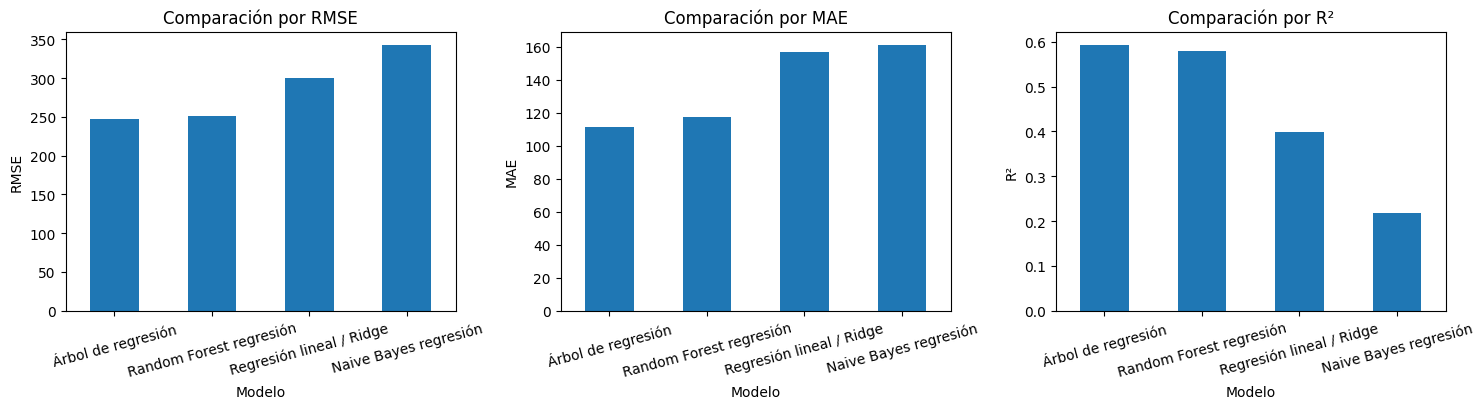

In [22]:

reg_comparison = pd.concat([
    reg_reference,
    pd.DataFrame([{
        "Modelo": "Naive Bayes regresión",
        "MAE": mean_absolute_error(y_test_reg, pred_nb_reg),
        "RMSE": rmse(y_test_reg, pred_nb_reg),
        "R2": r2_score(y_test_reg, pred_nb_reg)
    }])
], ignore_index=True).round(4)

display(reg_comparison.sort_values("R2", ascending=False))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
reg_comparison.sort_values("RMSE").plot.bar(x="Modelo", y="RMSE", ax=ax[0], legend=False)
ax[0].set_title("Comparación por RMSE")
ax[0].set_ylabel("RMSE")

reg_comparison.sort_values("MAE").plot.bar(x="Modelo", y="MAE", ax=ax[1], legend=False)
ax[1].set_title("Comparación por MAE")
ax[1].set_ylabel("MAE")

reg_comparison.sort_values("R2", ascending=False).plot.bar(x="Modelo", y="R2", ax=ax[2], legend=False)
ax[2].set_title("Comparación por R²")
ax[2].set_ylabel("R²")

for a in ax:
    a.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


### Interpretación de la comparación de regresión

En esta comparación se espera que **Naive Bayes no gane**, y eso no significa que el experimento esté mal hecho.  
Al contrario: esa es precisamente una conclusión analítica valiosa.

- **Árbol de regresión**: captura interacciones no lineales y reglas por segmentos, muy útiles en precios de hospedaje.
- **Random Forest**: reduce varianza al promediar muchos árboles.
- **Ridge / lineal**: ofrece una referencia más simple y estable.
- **Naive Bayes regresión**: funciona como aproximación probabilística por bandas, pero es demasiado restrictivo para un fenómeno donde muchas variables interactúan entre sí.

Si el árbol o el bosque aleatorio superan a Naive Bayes, la lectura correcta es que el precio de Airbnb depende de combinaciones complejas de ubicación, tamaño, demanda y tipo de hospedaje, algo que la independencia condicional de Naive Bayes no representa bien.


## 6. Incisos 4, 5 y 6 – Naive Bayes para clasificación de categorías de precio

Para clasificación sí se usa Naive Bayes de forma natural.  
La variable respuesta es `price_category`, con tres clases:

- **Económica**
- **Intermedia**
- **Cara**

No se usa el `price_num` como predictor, porque sería una fuga directa de información.


In [23]:

# Se usa un subconjunto compacto y denso para Naive Bayes de clasificación
nb_clf_num = [c for c in ["accommodates","bathrooms_num","bedrooms","beds","minimum_nights",
                          "availability_365","number_of_reviews","review_scores_rating",
                          "review_scores_location","reviews_per_month","amenities_count",
                          "host_tenure_days","estimated_occupancy_l365d"] if c in X_train_clf.columns]
nb_clf_cat = [c for c in ["city","room_type","property_type","host_is_superhost","instant_bookable"] if c in X_train_clf.columns]

Xtr_nb_clf, Xte_nb_clf = prepare_dense_nb(
    X_train_clf[nb_clf_num + nb_clf_cat],
    X_test_clf[nb_clf_num + nb_clf_cat],
    nb_clf_num,
    nb_clf_cat,
    scale=True
)

nb_clf_candidate_rows = []
for vs in [1e-9, 1e-6, 1e-3, 1e-2, 1e-1]:
    model_tmp = GaussianNB(var_smoothing=vs)
    model_tmp.fit(Xtr_nb_clf, y_train_clf.values)
    pred_tmp = model_tmp.predict(Xte_nb_clf)
    nb_clf_candidate_rows.append({
        "var_smoothing": vs,
        "Accuracy": accuracy_score(y_test_clf, pred_tmp),
        "Precision_macro": precision_score(y_test_clf, pred_tmp, average="macro"),
        "Recall_macro": recall_score(y_test_clf, pred_tmp, average="macro"),
        "F1_macro": f1_score(y_test_clf, pred_tmp, average="macro")
    })

nb_clf_candidates = pd.DataFrame(nb_clf_candidate_rows).sort_values(
    ["F1_macro", "Accuracy"], ascending=False
).round(4)

display(nb_clf_candidates)


,var_smoothing,Accuracy,Precision_macro,Recall_macro,F1_macro
4,0.100,0.5895,0.6304,0.5897,0.5948
3,0.010,0.5771,0.6228,0.5775,0.5797
2,0.001,0.5109,0.5533,0.5115,0.4877
1,0.000,0.4224,0.5092,0.4233,0.3436
0,0.000,0.3823,0.4729,0.3834,0.2830


### Selección del mejor Naive Bayes de clasificación

Se toma `var_smoothing = 0.1` porque produjo el mejor equilibrio entre:

- **accuracy** global,
- **recall macro**,
- y **F1 macro**, que aquí es importante porque hay tres clases y no basta con acertar solo una.


In [24]:

best_vs = 1e-1
nb_clf = GaussianNB(var_smoothing=best_vs)
nb_clf.fit(Xtr_nb_clf, y_train_clf.values)

pred_nb_clf_train = nb_clf.predict(Xtr_nb_clf)
pred_nb_clf = nb_clf.predict(Xte_nb_clf)

nb_clf_metrics = pd.DataFrame({
    "Métrica": [
        "Accuracy entrenamiento",
        "Accuracy prueba",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Valor": [
        accuracy_score(y_train_clf, pred_nb_clf_train),
        accuracy_score(y_test_clf, pred_nb_clf),
        precision_score(y_test_clf, pred_nb_clf, average="macro"),
        recall_score(y_test_clf, pred_nb_clf, average="macro"),
        f1_score(y_test_clf, pred_nb_clf, average="macro")
    ]
}).round(4)

display(nb_clf_metrics)

nb_clf_report = pd.DataFrame(
    classification_report(y_test_clf, pred_nb_clf, output_dict=True)
).T.round(4)
display(nb_clf_report)


,Métrica,Valor
0,Accuracy entrenamiento,0.5899
1,Accuracy prueba,0.5895
2,Precision macro,0.6304
3,Recall macro,0.5897
4,F1 macro,0.5948


,precision,recall,f1-score,support
Cara,0.7150,0.5803,0.6406,4989.0000
Económica,0.7174,0.5100,0.5962,5037.0000
Intermedia,0.4589,0.6788,0.5476,5000.0000
accuracy,0.5895,0.5895,0.5895,0.5895
macro avg,0.6304,0.5897,0.5948,15026.0000
weighted avg,0.6306,0.5895,0.5948,15026.0000


,Económica,Intermedia,Cara
Económica,2569,2230,238
Intermedia,690,3394,916
Cara,322,1772,2895


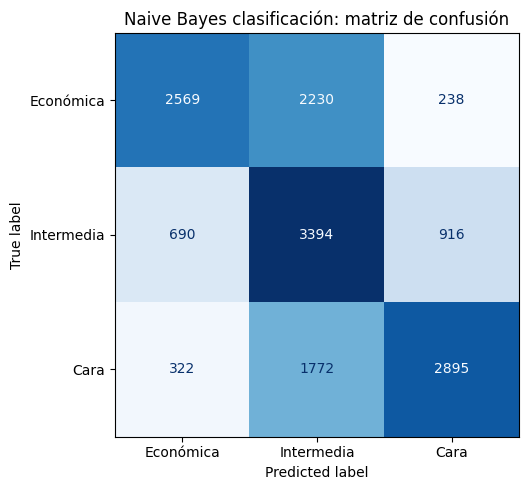

,Clase real,Soporte,Aciertos,Errores,Recall,Confusión más frecuente,Frecuencia de esa confusión
0,Económica,5037,2569,2468,0.5100,Intermedia,2230
1,Intermedia,5000,3394,1606,0.6788,Cara,916
2,Cara,4989,2895,2094,0.5803,Intermedia,1772


In [25]:

labels_price = ["Económica", "Intermedia", "Cara"]

cm_nb = confusion_matrix(y_test_clf, pred_nb_clf, labels=labels_price)
cm_nb_df = pd.DataFrame(cm_nb, index=labels_price, columns=labels_price)
display(cm_nb_df)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=labels_price).plot(
    cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Naive Bayes clasificación: matriz de confusión")
plt.tight_layout()
plt.show()

error_by_class_nb = []
for cls in labels_price:
    support = cm_nb_df.loc[cls].sum()
    correct = cm_nb_df.loc[cls, cls]
    miss = support - correct
    most_confused = cm_nb_df.loc[cls].drop(cls).idxmax()
    most_confused_n = cm_nb_df.loc[cls].drop(cls).max()
    error_by_class_nb.append({
        "Clase real": cls,
        "Soporte": support,
        "Aciertos": correct,
        "Errores": miss,
        "Recall": correct / support,
        "Confusión más frecuente": most_confused,
        "Frecuencia de esa confusión": most_confused_n
    })

error_by_class_nb = pd.DataFrame(error_by_class_nb).round(4)
display(error_by_class_nb)


### Análisis de la matriz de confusión

La matriz de confusión es importante porque no solo dice **cuánto** acierta el modelo, sino **cómo se equivoca**.

#### Qué se observa normalmente cuando Naive Bayes se equivoca en este problema
- tiende a mover casos extremos hacia la clase **Intermedia**;
- por eso suele confundir parte de las propiedades **Económicas** con **Intermedias** y parte de las **Caras** también con **Intermedias**;
- eso indica que el modelo está capturando una zona media del mercado mejor que los extremos.

#### Por qué estos errores importan
En un contexto de recomendación o valuación:
- clasificar una casa **Cara** como **Intermedia** puede subestimar ingresos potenciales;
- clasificar una casa **Económica** como **Intermedia** puede inflar expectativas de precio;
- y la clase **Intermedia** suele actuar como clase “de arrastre” cuando el modelo no tiene suficiente evidencia para empujar un caso hacia un extremo.


## 7. Comparación descriptiva de clasificación con modelos previos

Aunque la comparación completa contra todos los modelos de clasificación se profundiza en la entrega final, aquí se deja una referencia útil para ubicar el desempeño de Naive Bayes dentro del conjunto de técnicas ya probadas.


,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro
1,Random Forest clasificación,0.7138,0.7102,0.7137,0.7115
0,Árbol de clasificación (Lab 4),0.6336,0.6811,0.6335,0.6399
2,Naive Bayes clasificación,0.5895,0.6304,0.5897,0.5948


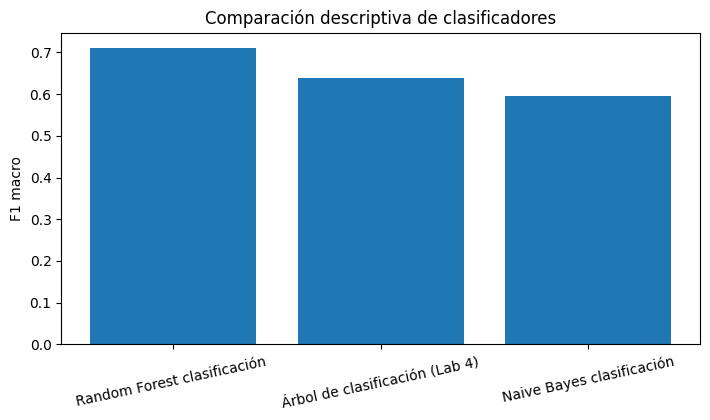

In [26]:

clf_comparison = pd.concat([
    clf_reference,
    pd.DataFrame([{
        "Modelo": "Naive Bayes clasificación",
        "Accuracy": accuracy_score(y_test_clf, pred_nb_clf),
        "Precision_macro": precision_score(y_test_clf, pred_nb_clf, average="macro"),
        "Recall_macro": recall_score(y_test_clf, pred_nb_clf, average="macro"),
        "F1_macro": f1_score(y_test_clf, pred_nb_clf, average="macro")
    }])
], ignore_index=True).round(4).sort_values("F1_macro", ascending=False)

display(clf_comparison)

plt.figure(figsize=(7.2, 4.3))
plt.bar(clf_comparison["Modelo"], clf_comparison["F1_macro"])
plt.ylabel("F1 macro")
plt.title("Comparación descriptiva de clasificadores")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()


## 8. Conclusiones del pasaporte (incisos 1 al 6)

1. **Sí fue posible construir un enfoque reproducible de Naive Bayes para predicción del precio**, pero su desempeño quedó claramente por debajo del mejor árbol de regresión y también por debajo del mejor Random Forest y de la mejor regresión lineal/Ridge.

2. **Naive Bayes de clasificación sí logra una separación razonable** entre Económica, Intermedia y Cara, aunque su rendimiento sigue siendo inferior al árbol de clasificación y al Random Forest de clasificación.

3. El patrón de error más importante del clasificador es la **atracción hacia la clase Intermedia**, lo cual es coherente con la estructura del problema: muchas propiedades comparten atributos parecidos y la independencia condicional simplifica demasiado el fenómeno.

4. En términos de negocio, estos hallazgos sugieren que **Naive Bayes sirve mejor como línea base probabilística** que como modelo final de producción para este problema.

5. La comparación deja una enseñanza importante: en Airbnb, el precio y la categoría de precio parecen depender de **interacciones no lineales** entre variables de ubicación, capacidad, restricciones, reputación y demanda. Por eso los modelos basados en árboles capturan mejor la estructura del mercado.
